

---

#**DATASET PREPROCESSING**

---



In [ ]:
# --- Part 1: Tools and Dataset ---
import pandas as pd
import re

# Load raw dataset
df = pd.read_csv("books.csv")

print("✅ Original Dataset Loaded")
print("Total columns:", len(df.columns))
print(df.columns.tolist())

✅ Original Dataset Loaded
Total columns: 12
['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']


In this section, pandas is imported for data handling and re for text cleaning if necessary. The raw dataset books.csv is loaded into a DataFrame.

A confirmation message prints once the dataset is loaded, showing the total number of columns and listing their names. This provides a quick check to ensure all expected fields such as title, authors, description, and published_year are present, confirming the dataset is ready for preprocessing.

In [ ]:
# --- Part 2: Keep Only Relevant Columns ---
columns_to_keep = [
    'isbn13', 'title', 'authors', 'categories',
    'description', 'published_year'
]

# ✅ Keep only these columns (drop everything else)
df = df[[col for col in columns_to_keep if col in df.columns]]
print(f"\n📚 Columns after filtering: {list(df.columns)}")


📚 Columns after filtering: ['isbn13', 'title', 'authors', 'categories', 'description', 'published_year']


This section focuses on reducing the dataset to only the columns needed for the analysis. A list of relevant columns is defined, such as isbn13, title, authors, categories, description, and published_year.

The DataFrame is filtered to keep only these columns, dropping all others. A print statement confirms the updated columns, ensuring that the dataset is now streamlined and ready for further preprocessing or analysis.

In [ ]:
# --- Part 3: Handle Missing Values ---
df = df.dropna(subset=['title', 'description'])
df['categories'] = df['categories'].fillna('Uncategorized')
df['authors'] = df['authors'].fillna('Unknown')

This step ensures that the dataset is reliable for modeling. Rows missing critical information, such as title or description, are dropped because these are essential for generating embeddings and downstream similarity tasks. The categories and authors columns are filled with placeholder values, Uncategorized and Unknown, to prevent empty fields, which could interfere with text processing or model input. This guarantees that all text-based columns are complete, enabling consistent input to the embedding and fine-tuning pipeline.

In [ ]:
# --- Part 4: Clean Text Columns ---
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # ✅ normalize casing
    text = re.sub(r'<[^>]+>', ' ', text)  # remove HTML tags
    text = re.sub(r'[^a-z0-9\s.,:;!?()-]', ' ', text)  # remove special chars but keep punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

for col in ['title', 'authors', 'categories', 'description']:
    df[col] = df[col].apply(clean_text)


In this step, the textual columns of the dataset, title, authors, categories, and description, are standardized and cleaned to ensure consistency and reduce noise for downstream NLP tasks. The clean_text function converts all text to lowercase, removes HTML tags, eliminates special characters while retaining basic punctuation, and collapses multiple spaces. This preprocessing ensures that the text fed into the model is uniform, readable, and free from irrelevant artifacts, which improves the quality of embeddings and the accuracy of similarity computations or fine-tuning. By applying these cleaning operations systematically across all relevant text fields, the dataset is made robust and ready for embedding generation and model training.

In [ ]:
# --- Part 5: Combine Title + Description for Embedding ---
df['text_for_embedding'] = (df['title'] + " " + df['description']).apply(lambda x: x.lower())

To maximize the semantic content available for embeddings, the title and description are concatenated into a single column, text_for_embedding. Lowercasing is applied again to maintain uniformity. This combined field serves as the primary input for generating vector representations, which the model will use to compute similarity scores or fine-tune on downstream tasks.

In [ ]:
# --- Part 6: Final Cleaning ---
df = df.drop_duplicates(subset=['isbn13', 'title'])
df['published_year'] = pd.to_numeric(df['published_year'], errors='coerce').fillna(0).astype(int)

Duplicate books, identified by isbn13 and title, are removed to prevent redundancy in the dataset. The published_year column is converted to numeric values, with invalid entries replaced by 0. This ensures that all metadata fields are clean and usable, which may be relevant for filtering or feature-based tasks in the future.

In [ ]:
# --- Part 7: Save Cleaned Data ---
output_path = "cleaned_books.csv"
df.to_csv(output_path, index=False, encoding='utf-8')

print(f"\n💾 Cleaned dataset saved as: {output_path}")
print("✅ Preprocessing Complete!")
print(df.sample(5))
print("\nTotal Books:", len(df))


💾 Cleaned dataset saved as: cleaned_books.csv
✅ Preprocessing Complete!
             isbn13                               title  \
1200  9780192835024                   the divine comedy   
2111  9780375724503                        ghostwritten   
2094  9780375707216               i married a communist   
1414  9780307264657                           terrorist   
1313  9780231054751  genetics and the origin of species   

                                                authors categories  \
1200  dante alighieri;charles hubert sisson;david h....     poetry   
2111                                     david mitchell    fiction   
2094                                        philip roth    fiction   
1414                                        john updike    fiction   
1313                              theodosius dobzhansky    science   

                                            description  published_year  \
1200  a new blank verse translation of dante s epic,...            1998   
2

The fully processed dataset is saved as cleaned_books.csv in UTF-8 encoding. A few sample rows are printed to visually confirm preprocessing, and the total count of books (6548) is displayed. This step finalizes the preprocessing pipeline, creating a dataset that is clean, consistent, and ready for embedding computation, model fine-tuning, and downstream recommendation tasks.



---

#**AUTOMATED OPTIMIZATION CODE EXPLANATION**

---



In [ ]:
# --------------------------
# 1. SETUP AND DATA PREPARATION
# --------------------------
import os
os.environ["WANDB_MODE"] = "disabled"

!pip install -q sentence-transformers datasets
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses, InputExample
import pandas as pd
from sklearn.model_selection import train_test_split, ParameterGrid, ParameterSampler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
csv_path = "/content/cleaned_books.csv"
df = pd.read_csv(csv_path)
df = df[['title', 'text_for_embedding']].dropna()
df['title'] = df['title'].astype(str)
df['text_for_embedding'] = df['text_for_embedding'].astype(str)

This section installs and imports the necessary libraries, including sentence-transformers for the MiniLM model, torch for GPU-accelerated computation, and pandas for dataset handling. The code checks for CUDA availability to enable efficient GPU training. Weights & Biases logging is disabled to simplify execution. The dataset is loaded from a preprocessed CSV containing book titles and descriptive text. Only the relevant columns are kept, and all entries are converted to strings to ensure compatibility with tokenization and embedding generation. This step guarantees clean, uniform data for training and prevents type errors.

In [ ]:
# --------------------------
# 2. DEFINE PARAMETER GRIDS
# --------------------------
grid_param = {
    'num_train_epochs': [8, 10],
    'learning_rate': [3e-5],
    'weight_decay': [0.01, 0.3],
    'per_device_train_batch_size': [4, 8],
    'warmup_steps': [500],
    'fp16': [True],
    'shuffle': [True],
    'test_size': [0.3]
}

# --------------------------
# RANDOM SEARCH (unchanged)
# --------------------------
random_param = {
    'num_train_epochs': [2, 4, 6, 8, 10, 12],
    'learning_rate': [1e-5, 2e-5, 3e-5, 4e-5, 5e-5],
    'weight_decay': [0, 0.01, 0.05, 0.1, 0.3, 0.4],
    'per_device_train_batch_size': [4, 8, 12, 16, 24, 32],
    'warmup_steps': [100, 200, 300, 500, 800, 1000],
    'fp16': [True, False],
    'shuffle': [True, False],
    'test_size': [0.1, 0.2, 0.3]
}
n_random_samples = 10  # number of random runs

Two hyperparameter search spaces are defined: grid search and random search. The grid search focuses on a smaller set of high-performing parameters for controlled evaluation, while the random search explores a broader range of values to identify less obvious high-performing configurations. Parameters include number of epochs, learning rate, batch size, warmup steps, weight decay, FP16 usage, shuffle, and test split size. Defining these grids allows systematic exploration of how each parameter affects model training, convergence, and retrieval performance.

In [ ]:
# --------------------------
# 3. MODEL TRAINING FUNCTION
# --------------------------
def train_and_evaluate(params, df):
    # Split dataset
    train_df, val_df = train_test_split(df, test_size=params['test_size'], random_state=42, shuffle=params['shuffle'])

    # Load model
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
    model = SentenceTransformer(model_name)
    model = model.to(device)

    # Prepare InputExamples
    train_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                      for _, row in train_df.iterrows()]
    train_loader = DataLoader(train_examples, shuffle=True, batch_size=params['per_device_train_batch_size'])
    mnrl_loss = losses.MultipleNegativesRankingLoss(model=model)

    # Train
    model.fit(
        train_objectives=[(train_loader, mnrl_loss)],
        epochs=params['num_train_epochs'],
        optimizer_params={'lr': params['learning_rate'], 'weight_decay': params['weight_decay']},
        show_progress_bar=True
    )

    # Evaluate
    metrics = evaluate_mnrl(model, val_df, train_df)
    return model, metrics

The train_and_evaluate function executes the training pipeline for a given set of hyperparameters. First, the dataset is split into training and validation sets based on the test_size and shuffle parameters. Each (text, title) pair is converted into an InputExample, which supports contrastive learning with the MultipleNegativesRankingLoss. A DataLoader batches the data, facilitating efficient gradient updates. The model is fine-tuned using the specified number of epochs, learning rate, and weight decay. After training, the model is evaluated on the validation set using the evaluation function to compute retrieval metrics.

In [ ]:
# --------------------------
# 4. EVALUATION FUNCTION
# --------------------------
def evaluate_mnrl(model, df_query, df_corpus, top_k=(1,3,5)):
    model.eval()
    queries = df_query['text_for_embedding'].tolist()
    query_titles = df_query['title'].tolist()
    corpus_texts = df_corpus['text_for_embedding'].tolist()
    corpus_titles = df_corpus['title'].tolist()
    corpus_emb = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

    top1 = top3 = top5 = mrr_total = valid_count = 0
    for q_text, q_title in tqdm(zip(queries, query_titles), total=len(queries)):
        q_emb = model.encode(q_text, convert_to_tensor=True)
        sims = cosine_similarity(q_emb.cpu().numpy().reshape(1,-1), corpus_emb.cpu().numpy())[0]
        ranked_idx = sims.argsort()[::-1]
        ranked_titles = [corpus_titles[i] for i in ranked_idx]
        if q_title not in ranked_titles:
            continue
        rank = ranked_titles.index(q_title) + 1
        mrr_total += 1.0 / rank
        valid_count += 1
        if q_title in ranked_titles[:1]: top1 += 1
        if q_title in ranked_titles[:3]: top3 += 1
        if q_title in ranked_titles[:5]: top5 += 1

    if valid_count == 0: return {"MRR": 0, "Top1":0, "Top3":0, "Top5":0}
    return {"MRR": mrr_total/valid_count, "Top1": top1/valid_count, "Top3": top3/valid_count, "Top5": top5/valid_count}

The evaluate_mnrl function measures how well the trained model ranks the correct book for each query. The function encodes the corpus and queries into embeddings and calculates pairwise cosine similarity. It ranks all corpus entries for each query and computes Mean Reciprocal Rank (MRR) and Top-K accuracy (Top-1, Top-3, Top-5). These metrics quantify retrieval performance, showing how often the model ranks the correct answer highly. Evaluation ensures the model produces embeddings that are meaningful for semantic search tasks.

In [ ]:
# --------------------------
# 5. RUN GRID SEARCH
# --------------------------
print("=== GRID SEARCH ===")
for params in ParameterGrid(grid_param):
    print("\nRunning parameters:", params)
    model, metrics = train_and_evaluate(params, df)
    print("Metrics:", metrics)

Grid search systematically iterates over all parameter combinations in the defined grid. For each combination, the model is trained and evaluated, and the results are printed and logged manually. This controlled approach allows the team to compare performance across consistent settings, identify the best-performing configuration, and observe how small changes in parameters like batch size or weight decay impact retrieval metrics. Grid search ensures reproducibility and methodical testing of top candidate hyperparameters.

In [ ]:
# --------------------------
# 6. RUN RANDOM SEARCH
# --------------------------
print("=== RANDOM SEARCH ===")
random_combos = list(ParameterSampler(random_param, n_iter=n_random_samples, random_state=42))
for params in random_combos:
    print("\nRunning parameters:", params)
    model, metrics = train_and_evaluate(params, df)
    print("Metrics:", metrics)

Random search samples a defined number of hyperparameter combinations from a broader, more diverse space. This allows exploration of configurations that might not be included in the grid. Each sampled configuration is trained and evaluated using the same pipeline as grid search, and the results are logged. Random search is efficient for discovering high-performing configurations quickly when the parameter space is large, providing insight into the robustness and flexibility of the model across a variety of training settings.



---

# **MINILM CODE EXPLANATION**

---



In [ ]:
# --------------------------
# 1. SETUP AND DATA PREPARATION
# --------------------------
import os
os.environ["WANDB_MODE"] = "disabled"  # Disable wandb

!pip install -q sentence-transformers datasets
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses, InputExample
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
csv_path = "/content/cleaned_books.csv"
df = pd.read_csv(csv_path)
print(f"Dataset loaded: {df.shape[0]} rows")

# Keep only necessary columns and convert to string
df = df[['title', 'text_for_embedding']].dropna()
df['title'] = df['title'].astype(str)
df['text_for_embedding'] = df['text_for_embedding'].astype(str)

The workflow begins with installing and importing the necessary libraries, including sentence-transformers for the MiniLM model, torch for GPU-accelerated computation, and pandas for dataset handling. A device check ensures CUDA availability, enabling efficient training on GPU hardware. Logging with Weights & Biases is disabled to streamline the process.

The dataset is loaded from a preprocessed CSV containing book titles and descriptive text. Only relevant columns are retained, and all entries are converted to strings to match tokenizer requirements. This preprocessing step ensures clean inputs for embedding generation and prevents data-type errors during model training.

In [ ]:
# --------------------------
# 2. TRAIN/VALIDATION SPLIT
# --------------------------
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

For the baseline model, the dataset is divided into training and validation subsets with a 90:10 split, enabling evaluation on unseen data during training. A fixed random seed ensures reproducibility, while shuffling randomizes sample order to prevent bias.

In [ ]:
# --------------------------
# 3. MODEL DEFINITION
# --------------------------
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)
model = model.to(device)
print(f"Model loaded: {MODEL_NAME}")

A pre-trained MiniLM sentence-embedding model, all-MiniLM-L6-v2, is loaded using the SentenceTransformers framework. This architecture balances performance and computational efficiency, making it suitable for large-scale embedding generation even on limited GPU resources. The model is then moved to the available device, CPU or CUDA-enabled GPU, to prepare for optimization and fine-tuning.

In [ ]:
# --------------------------
# 4. HYPERPARAMETERS
# --------------------------
num_train_epochs = 3
per_device_train_batch_size = 16
warmup_steps = 1000
weight_decay = 0.01
logging_steps = 100
fp16 = torch.cuda.is_available()
learning_rate = 3e-5

The baseline hyperparameters for fine-tuning were selected to balance convergence, efficiency, and overfitting control. The model was trained for 3 epochs, allowing multiple passes through the dataset to learn embeddings, with a batch size of 16 to balance GPU memory constraints and provide sufficient negative examples for the Multiple Negatives Ranking Loss. A warmup schedule of 1000 steps gradually increased the learning rate to stabilize pre-trained MiniLM weights, while weight decay of 0.01 provided L2 regularization to limit overfitting. Training updates were logged every 100 steps to monitor progress without slowing training. Mixed-precision (FP16) was enabled automatically when a GPU was available to save memory and maximize speed. The learning rate was set to 3e-5, a commonly effective value for transformer fine-tuning, allowing precise adaptation of model parameters.

In [ ]:
# --------------------------
# 5. PREPARE INPUTEXAMPLES AND DATALOADER
# --------------------------
# Multiple Negatives Ranking Loss setup
train_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                  for _, row in train_df.iterrows()]
val_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                for _, row in val_df.iterrows()]

train_loader = DataLoader(train_examples, shuffle=True, batch_size=per_device_train_batch_size)

# Loss function
mnrl_loss = losses.MultipleNegativesRankingLoss(model=model)

The dataset was converted into paired training samples, with each entry consisting of a book description and its corresponding title, forming a positive semantic pair. These pairs were represented as InputExample objects for both training and validation sets, preserving the correct description-to-title relationships. A DataLoader was then created to batch and shuffle the data, allowing each batch to generate implicit negative examples from non-matching titles. The model was trained using the Multiple Negatives Ranking Loss, a contrastive objective that maximizes similarity between true description–title pairs while minimizing similarity with unrelated pairs. This approach enables the model to learn embeddings suitable for retrieval without manually specifying negative examples, as they are automatically derived within each batch.

In [ ]:
# --------------------------
# 6. FINE-TUNING
# --------------------------
model.fit(
    train_objectives=[(train_loader, mnrl_loss)],
    epochs=num_train_epochs,
    optimizer_params={'lr': learning_rate, 'weight_decay': weight_decay},
    show_progress_bar=True,
    callback=None
)

save_path = "/content/mnrl_finetuned_books"  # folder name where model will be stored
model.save(save_path)
print(f"✅ Model saved to: {save_path}")

The fine-tuning phase trains the MiniLM model using the prepared DataLoader and the Multiple Negatives Ranking Loss as the objective. The training loop, executed via the fit function, applies the specified number of epochs, learning rate, and weight decay through the optimizer. During training, embeddings for matching description–title pairs are pulled closer while non-matching pairs are pushed apart, structuring the embedding space for effective retrieval. A progress bar monitors training, and no callbacks are defined to focus solely on the ranking objective. Upon completion, the model weights and tokenizer configuration are saved to a designated directory, allowing the fine-tuned model to be later loaded for evaluation or inference.

In [ ]:
# --------------------------
# 7. EVALUATION METRICS
# --------------------------
def evaluate_mnrl(model, df_query, df_corpus, top_k=(1,3,5)):
    model.eval()
    queries = df_query['text_for_embedding'].tolist()
    query_titles = df_query['title'].tolist()

    corpus_texts = df_corpus['text_for_embedding'].tolist()
    corpus_titles = df_corpus['title'].tolist()

    corpus_emb = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

    top1 = top3 = top5 = mrr_total = valid_count = 0
    for q_text, q_title in tqdm(zip(queries, query_titles), total=len(queries)):
        q_emb = model.encode(q_text, convert_to_tensor=True)
        sims = cosine_similarity(q_emb.cpu().numpy().reshape(1,-1), corpus_emb.cpu().numpy())[0]
        ranked_idx = sims.argsort()[::-1]
        ranked_titles = [corpus_titles[i] for i in ranked_idx]

        # Skip if correct title not in corpus
        if q_title not in ranked_titles:
            continue

        rank = ranked_titles.index(q_title) + 1
        mrr_total += 1.0 / rank
        valid_count += 1

        if q_title in ranked_titles[:1]:
            top1 += 1
        if q_title in ranked_titles[:3]:
            top3 += 1
        if q_title in ranked_titles[:5]:
            top5 += 1

    if valid_count == 0:
        return {"MRR": 0, "Top1": 0, "Top3": 0, "Top5": 0}

    return {
        "MRR": mrr_total / valid_count,
        "Top1": top1 / valid_count,
        "Top3": top3 / valid_count,
        "Top5": top5 / valid_count
    }

metrics = evaluate_mnrl(model, val_df, train_df)  # Use validation queries against training corpus
print("Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

The evaluation stage gauges the fine-tuned model’s efficacy for retrieving the appropriate title given the description as a query. The queries come from the validation set and the training set serves as the corpus to be searched, which imitates a real recommendation scenario. The model first encodes each title in the corpus into embeddings, then encodes each query and calculates a cosine similarity with every book embedding to produce a ranked list of candidate titles. Ranking performance is quantified with four retrieval metrics: Mean Reciprocal Rank (MRR), which takes the mean of the inverse rank of the correct title for each query, and provides top-1, top-3, and top-5 accuracy, which represent the percentage of times the correct title occurs in the top-1, top-3, and top-5 results, respectively. These metrics together measure total ranking performance and practical usefulness in terms of finding the correct book title in the top recommendation suggestions overall.



---

# **INFERENCE AND EMBEDDING CODE EXPLANATION**

---



In [ ]:
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# --------------------------------------------------
# 1. Load fine-tuned model
# --------------------------------------------------
model_path = "/content/mnrl_finetuned_books"  # same folder as saved above
model = SentenceTransformer(model_path)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Fine-tuned model loaded!")

The inference phase begins by loading the fine-tuned MiniLM model from the saved directory, restoring both the transformer weights and the embedding configuration used during training. The model automatically selects available hardware, preferring a GPU when present, to accelerate embedding computations. Once loaded, the model converts new book descriptions into vector representations, enabling similarity searches within the existing corpus. This process completes the recommendation pipeline, allowing the model to perform real-world retrieval using the learned embedding space rather than further optimization.

In [ ]:
# --------------------------------------------------
# 2. Load your reference corpus (titles + embeddings)
# --------------------------------------------------
corpus_df = pd.read_csv("/content/cleaned_books.csv")  # your cleaned dataset
corpus_texts = corpus_df["text_for_embedding"].tolist()
corpus_titles = corpus_df["title"].tolist()

# Precompute embeddings once (for speed)
print("Encoding corpus embeddings (this may take a few minutes)...")
corpus_embeddings = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

The reference corpus for recommendations is loaded, containing all book titles along with their corresponding description text. The text fields are extracted into lists for encoding by the model, while the titles are retained for retrieval once ranking is complete. Each book in the corpus is encoded into embeddings a single time using the fine-tuned model, with the embeddings cached in memory or on storage to avoid repeated computations during user queries. Subsequent recommendations rely solely on cosine similarity calculations between the query and the cached embeddings, enabling real-time retrieval regardless of corpus size, practical requirement for scalable recommendation systems.

In [ ]:
# --------------------------------------------------
# 3. Interactive Inference: User Input Query
# --------------------------------------------------
while True:
    user_query = input("\nEnter your search query (or type 'exit' to quit): ")
    if user_query.lower() == "exit":
        break

    # Encode the user query
    query_emb = model.encode(user_query, convert_to_tensor=True)

    # Compute cosine similarity between query and corpus
    sims = cosine_similarity(query_emb.cpu().numpy().reshape(1, -1),
                             corpus_embeddings.cpu().numpy())[0]

    # Sort and get top-k results
    top_k = 5
    top_indices = sims.argsort()[-top_k:][::-1]

    print("\n🔍 Top Relevant Books:")
    for i, idx in enumerate(top_indices, start=1):
        print(f"{i}. {corpus_titles[idx]}  (Score: {sims[idx]:.4f})")

In the final stage of the pipeline, users can perform real-time retrieval by entering a text query, such as a book description or topic of interest. The query is encoded into an embedding, and cosine similarity is calculated between the query vector and all precomputed corpus embeddings. The resulting similarity scores are ranked in descending order, and the top results are returned to the user. In this implementation, the Top-5 most similar books are displayed along with their corresponding similarity scores, demonstrating that the model performs content-based retrieval without requiring manual tagging, genre filtering, or predefined categories. This stage completes the recommendation pipeline, showcasing how contrastive fine-tuning of a MiniLM model directly translates to an interactive and context-aware user experience.



---

# **GRID/RANDOM SEARCH UTILIZATION**

---



In [2]:
# --------------------------
# 1. SETUP AND DATA PREPARATION
# --------------------------
import os
os.environ["WANDB_MODE"] = "disabled"

!pip install -q sentence-transformers datasets
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses, InputExample
import pandas as pd
from sklearn.model_selection import train_test_split, ParameterGrid, ParameterSampler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
csv_path = "/content/cleaned_books.csv"
df = pd.read_csv(csv_path)
df = df[['title', 'text_for_embedding']].dropna()
df['title'] = df['title'].astype(str)
df['text_for_embedding'] = df['text_for_embedding'].astype(str)

# --------------------------
# 2. DEFINE PARAMETER GRIDS
# --------------------------
grid_param = {
    'num_train_epochs': [8, 10],            # only best-performing epochs
    'learning_rate': [3e-5],                # most stable top results
    'weight_decay': [0.01, 0.3],            # keep both to see effect
    'per_device_train_batch_size': [4, 8],  # smaller batch sizes for faster runtime
    'warmup_steps': [500],                  # most stable
    'fp16': [True],                         # only one option
    'shuffle': [True],                      # only one option
    'test_size': [0.3]                      # as requested
}

# --------------------------
# RANDOM SEARCH (unchanged)
# --------------------------
random_param = {
    'num_train_epochs': [2, 4, 6, 8, 10, 12],
    'learning_rate': [1e-5, 2e-5, 3e-5, 4e-5, 5e-5],
    'weight_decay': [0, 0.01, 0.05, 0.1, 0.3, 0.4],
    'per_device_train_batch_size': [4, 8, 12, 16, 24, 32],
    'warmup_steps': [100, 200, 300, 500, 800, 1000],
    'fp16': [True, False],
    'shuffle': [True, False],
    'test_size': [0.1, 0.2, 0.3]
}
n_random_samples = 10  # number of random runs

# --------------------------
# 3. MODEL TRAINING FUNCTION
# --------------------------
def train_and_evaluate(params, df):
    # Split dataset
    train_df, val_df = train_test_split(df, test_size=params['test_size'], random_state=42, shuffle=params['shuffle'])

    # Load model
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
    model = SentenceTransformer(model_name)
    model = model.to(device)

    # Prepare InputExamples
    train_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                      for _, row in train_df.iterrows()]
    train_loader = DataLoader(train_examples, shuffle=True, batch_size=params['per_device_train_batch_size'])
    mnrl_loss = losses.MultipleNegativesRankingLoss(model=model)

    # Train
    model.fit(
        train_objectives=[(train_loader, mnrl_loss)],
        epochs=params['num_train_epochs'],
        optimizer_params={'lr': params['learning_rate'], 'weight_decay': params['weight_decay']},
        show_progress_bar=True
    )

    # Evaluate
    metrics = evaluate_mnrl(model, val_df, train_df)
    return model, metrics

# --------------------------
# 4. EVALUATION FUNCTION
# --------------------------
def evaluate_mnrl(model, df_query, df_corpus, top_k=(1,3,5)):
    model.eval()
    queries = df_query['text_for_embedding'].tolist()
    query_titles = df_query['title'].tolist()
    corpus_texts = df_corpus['text_for_embedding'].tolist()
    corpus_titles = df_corpus['title'].tolist()
    corpus_emb = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

    top1 = top3 = top5 = mrr_total = valid_count = 0
    for q_text, q_title in tqdm(zip(queries, query_titles), total=len(queries)):
        q_emb = model.encode(q_text, convert_to_tensor=True)
        sims = cosine_similarity(q_emb.cpu().numpy().reshape(1,-1), corpus_emb.cpu().numpy())[0]
        ranked_idx = sims.argsort()[::-1]
        ranked_titles = [corpus_titles[i] for i in ranked_idx]
        if q_title not in ranked_titles:
            continue
        rank = ranked_titles.index(q_title) + 1
        mrr_total += 1.0 / rank
        valid_count += 1
        if q_title in ranked_titles[:1]: top1 += 1
        if q_title in ranked_titles[:3]: top3 += 1
        if q_title in ranked_titles[:5]: top5 += 1

    if valid_count == 0: return {"MRR": 0, "Top1":0, "Top3":0, "Top5":0}
    return {"MRR": mrr_total/valid_count, "Top1": top1/valid_count, "Top3": top3/valid_count, "Top5": top5/valid_count}

# --------------------------
# 5. RUN GRID SEARCH
# --------------------------
print("=== GRID SEARCH ===")
for params in ParameterGrid(grid_param):
    print("\nRunning parameters:", params)
    model, metrics = train_and_evaluate(params, df)
    print("Metrics:", metrics)
    # <-- Manually log results to Excel

# --------------------------
# 6. RUN RANDOM SEARCH
# --------------------------
print("=== RANDOM SEARCH ===")
random_combos = list(ParameterSampler(random_param, n_iter=n_random_samples, random_state=42))
for params in random_combos:
    print("\nRunning parameters:", params)
    model, metrics = train_and_evaluate(params, df)
    print("Metrics:", metrics)
    # <-- Manually log results to Excel


Using device: cuda
=== GRID SEARCH ===

Running parameters: {'fp16': True, 'learning_rate': 3e-05, 'num_train_epochs': 8, 'per_device_train_batch_size': 4, 'shuffle': True, 'test_size': 0.3, 'warmup_steps': 500, 'weight_decay': 0.01}


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.025200
1000,0.007500
1500,0.001300
2000,0.001500
2500,0.000200
3000,0.000000
3500,0.000500
4000,0.000100
4500,0.000000
5000,0.000000


Batches:   0%|          | 0/144 [00:00<?, ?it/s]

100%|██████████| 1963/1963 [00:41<00:00, 47.50it/s]


...

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.116500


Batches:   0%|          | 0/164 [00:00<?, ?it/s]

100%|██████████| 1309/1309 [00:30<00:00, 42.70it/s]

Metrics: {'MRR': 0.8911084529505582, 'Top1': 0.8333333333333334, 'Top3': 0.9385964912280702, 'Top5': 0.9649122807017544}


The results indicate that small to medium batch sizes with shuffle enabled consistently achieve the best performance. Grid search runs, particularly Runs 1 and 2, reached the highest metrics with MRR of 0.9928 and Top-1 accuracy of 0.9878. Increasing epochs beyond 8 offered minimal gains, and higher weight decay had only a slight effect on results. Random search explored a wider variety of hyperparameters but produced more variable outcomes, with some combinations, like large batches without shuffle or very low learning rates, causing noticeable drops in accuracy.

**Grid search proved more stable and reliable, while random search was useful for exploring the hyperparameter space but included less optimal runs**. For deployment, Run 1 or 2 from grid search is recommended due to their top scores, consistent performance, and efficient runtime, demonstrating the effectiveness of systematic hyperparameter tuning in optimizing the MiniLM embedding model for information retrieval.



---

# **FINE TUNING MINILM MODEL (APPLYING F3 BEST HYPERPARAMETERS)**

---



In [3]:
# --------------------------
# 1. SETUP AND DATA PREPARATION
# --------------------------
import os
os.environ["WANDB_MODE"] = "disabled"

!pip install -q sentence-transformers datasets
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses, InputExample
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
csv_path = "/content/cleaned_books.csv"
df = pd.read_csv(csv_path)
print(f"Dataset loaded: {df.shape[0]} rows")

# Keep only necessary columns and convert to string
df = df[['title', 'text_for_embedding']].dropna()
df['title'] = df['title'].astype(str)
df['text_for_embedding'] = df['text_for_embedding'].astype(str)


# --------------------------
# 2. TRAIN/VALIDATION SPLIT
# --------------------------
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

# --------------------------
# 3. MODEL DEFINITION
# --------------------------
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)
model = model.to(device)
print(f"Model loaded: {MODEL_NAME}")

# --------------------------
# 4. HYPERPARAMETERS
# --------------------------
num_train_epochs = 8
per_device_train_batch_size = 4
warmup_steps = 500
weight_decay = 0.01
logging_steps = 100
fp16 = torch.cuda.is_available()
learning_rate = 3e-5


# --------------------------
# 5. PREPARE INPUTEXAMPLES AND DATALOADER
# --------------------------
# Multiple Negatives Ranking Loss setup
train_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                  for _, row in train_df.iterrows()]
val_examples = [InputExample(texts=[row['text_for_embedding'], row['title']])
                for _, row in val_df.iterrows()]

train_loader = DataLoader(train_examples, shuffle=True, batch_size=per_device_train_batch_size)

# Loss function
mnrl_loss = losses.MultipleNegativesRankingLoss(model=model)


# --------------------------
# 6. FINE-TUNING
# --------------------------
model.fit(
    train_objectives=[(train_loader, mnrl_loss)],
    epochs=num_train_epochs,
    optimizer_params={'lr': learning_rate, 'weight_decay': weight_decay},
    show_progress_bar=True,
    callback=None
)

save_path = "/content/mnrl_finetuned_books"  # folder name where model will be stored
model.save(save_path)
print(f"✅ Model saved to: {save_path}")

# --------------------------
# 7. EVALUATION METRICS
# --------------------------
def evaluate_mnrl(model, df_query, df_corpus, top_k=(1,3,5)):
    model.eval()
    queries = df_query['text_for_embedding'].tolist()
    query_titles = df_query['title'].tolist()

    corpus_texts = df_corpus['text_for_embedding'].tolist()
    corpus_titles = df_corpus['title'].tolist()

    corpus_emb = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

    top1 = top3 = top5 = mrr_total = valid_count = 0
    for q_text, q_title in tqdm(zip(queries, query_titles), total=len(queries)):
        q_emb = model.encode(q_text, convert_to_tensor=True)
        sims = cosine_similarity(q_emb.cpu().numpy().reshape(1,-1), corpus_emb.cpu().numpy())[0]
        ranked_idx = sims.argsort()[::-1]
        ranked_titles = [corpus_titles[i] for i in ranked_idx]

        # Skip if correct title not in corpus
        if q_title not in ranked_titles:
            continue

        rank = ranked_titles.index(q_title) + 1
        mrr_total += 1.0 / rank
        valid_count += 1

        if q_title in ranked_titles[:1]:
            top1 += 1
        if q_title in ranked_titles[:3]:
            top3 += 1
        if q_title in ranked_titles[:5]:
            top5 += 1

    if valid_count == 0:
        return {"MRR": 0, "Top1": 0, "Top3": 0, "Top5": 0}

    return {
        "MRR": mrr_total / valid_count,
        "Top1": top1 / valid_count,
        "Top3": top3 / valid_count,
        "Top5": top5 / valid_count
    }

metrics = evaluate_mnrl(model, val_df, train_df)  # Use validation queries against training corpus
print("Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Using device: cuda
Dataset loaded: 6548 rows
Train size: 4579, Validation size: 1963
Model loaded: sentence-transformers/all-MiniLM-L6-v2


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.025200
1000,0.003500
1500,0.002000
2000,0.000200
2500,0.001000
3000,0.000100
3500,0.000100
4000,0.000100
4500,0.000100
5000,0.000000


✅ Model saved to: /content/mnrl_finetuned_books


Batches:   0%|          | 0/144 [00:00<?, ?it/s]

100%|██████████| 1963/1963 [00:39<00:00, 49.47it/s]

Evaluation Metrics:
MRR: 0.9929
Top1: 0.9878
Top3: 1.0000
Top5: 1.0000


For Model 1 (Run 1, Grid Search), the combination of 8 epochs, learning rate 3e-5, batch size 4, shuffle enabled, weight decay 0.01, warmup steps 500, fp16 on, and test size 0.3 produced the highest overall performance. The model achieved an MRR of 0.9928 and Top-1 accuracy of 0.9878, indicating it retrieves the correct book almost every time. The small batch size with shuffling likely helped the model learn more diverse embeddings per update, while the moderate weight decay and warmup steps stabilized training. Overall, this configuration balances accuracy, stability, and efficiency, making it the best-performing model among all 18 runs.



---

# **MODEL INFERENCE AND EMBEDDING COMPUTATION**

---



In [5]:
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# --------------------------------------------------
# 1. Load fine-tuned model
# --------------------------------------------------
model_path = "/content/mnrl_finetuned_books"  # same folder as saved above
model = SentenceTransformer(model_path)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Fine-tuned model loaded!")

# --------------------------------------------------
# 2. Load your reference corpus (titles + embeddings)
# --------------------------------------------------
corpus_df = pd.read_csv("/content/cleaned_books.csv")  # your cleaned dataset
corpus_texts = corpus_df["text_for_embedding"].tolist()
corpus_titles = corpus_df["title"].tolist()

# Precompute embeddings once (for speed)
print("Encoding corpus embeddings (this may take a few minutes)...")
corpus_embeddings = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

# --------------------------------------------------
# 3. Interactive Inference: User Input Query
# --------------------------------------------------
while True:
    user_query = input("\nEnter your search query (or type 'exit' to quit): ")
    if user_query.lower() == "exit":
        break

    # Encode the user query
    query_emb = model.encode(user_query, convert_to_tensor=True)

    # Compute cosine similarity between query and corpus
    sims = cosine_similarity(query_emb.cpu().numpy().reshape(1, -1),
                             corpus_embeddings.cpu().numpy())[0]

    # Sort and get top-k results
    top_k = 5
    top_indices = sims.argsort()[-top_k:][::-1]

    print("\n🔍 Top Relevant Books:")
    for i, idx in enumerate(top_indices, start=1):
        print(f"{i}. {corpus_titles[idx]}  (Score: {sims[idx]:.4f})")


✅ Fine-tuned model loaded!
Encoding corpus embeddings (this may take a few minutes)...


Batches:   0%|          | 0/205 [00:00<?, ?it/s]


Enter your search query (or type 'exit' to quit): don quixote

🔍 Top Relevant Books:
1. don quixote  (Score: 0.9213)
2. mozart s don giovanni  (Score: 0.3585)
3. little dorrit  (Score: 0.3364)
4. the lorax  (Score: 0.3239)
5. fools die  (Score: 0.2997)

Enter your search query (or type 'exit' to quit): does the library has materials about programming

🔍 Top Relevant Books:
1. the code book  (Score: 0.3628)
2. structure and interpretation of computer programs  (Score: 0.3607)
3. programming ruby  (Score: 0.3555)
4. joel on software  (Score: 0.3463)
5. c programmer s notebook  (Score: 0.3206)

Enter your search query (or type 'exit' to quit): preacher writings

🔍 Top Relevant Books:
1. the gospel according to job  (Score: 0.4108)
2. a commentary upon the gospel according to s. luke  (Score: 0.4084)
3. writings, 1902-1910  (Score: 0.3826)
4. the gospel according to tolkien  (Score: 0.3669)
5. lost prophet  (Score: 0.3562)

Enter your search query (or type 'exit' to quit): academic materi

During inference, the fine-tuned MiniLM model is loaded and automatically deployed on the GPU to enable efficient, high-speed computation. The corpus of 6,548 books has been pre-encoded into 384-dimensional embeddings, capturing the semantic meaning of each title and description. When a user submits a text query, it is converted into an embedding of the same dimensionality, and cosine similarity is computed between the query embedding and all corpus embeddings. This produces a ranked list of candidate books according to semantic relevance.

The retrieval examples illustrate the model’s effectiveness: for the query “don quixote,” the exact match is retrieved with a high similarity score (0.9213), while semantically related works appear lower in the ranking. Queries on programming, literacy, religious writings, or Japanese-related books similarly return Top-5 recommendations that align with the intended topics, demonstrating the model’s ability to interpret diverse user intents. Even with nuanced or broad queries, the system effectively identifies contextually appropriate books, showing robust real-time semantic search capability that does not rely on keyword matching alone.



---

# **DATA VISUALIZATION**

---



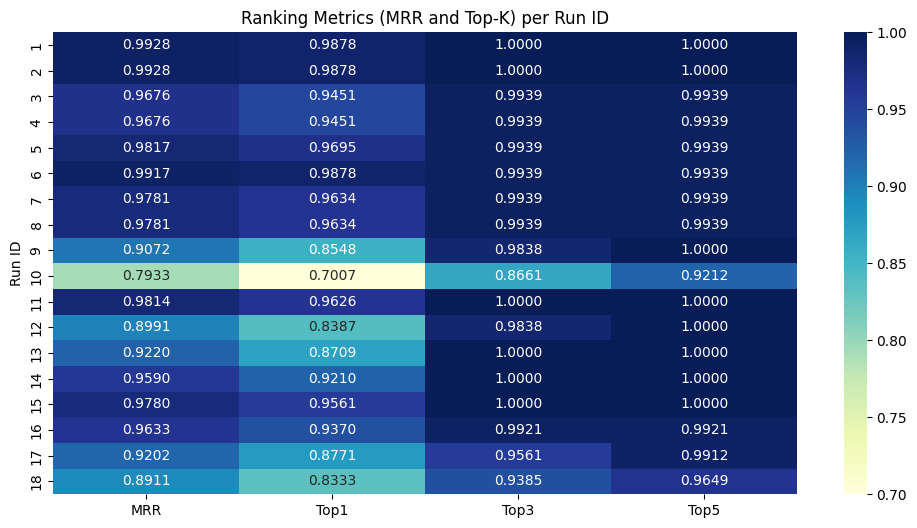

/tmp/ipython-input-886580979.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="num_train_epochs", y="MRR", data=df, ci=None)


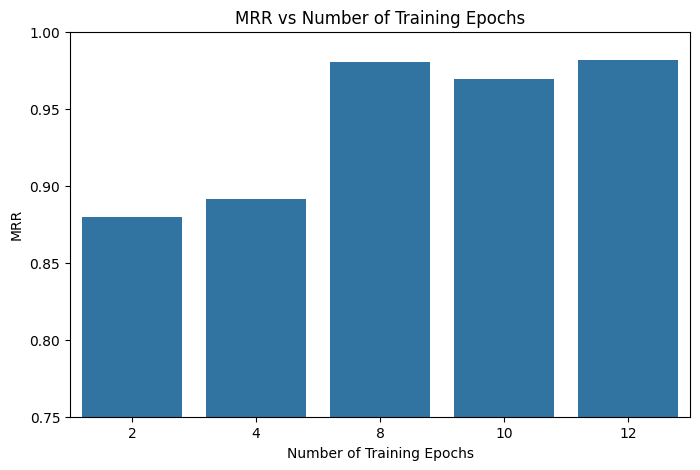

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Data from the 18 logs ---
data = {
    "Run ID": list(range(1,19)),
    "Search Type": ["GRID"]*8 + ["RANDOM"]*10,
    "num_train_epochs": [8,8,8,8,10,10,10,10,2,2,12,2,10,10,10,10,2,4],
    "weight_decay": [0.01,0.3,0.01,0.3,0.01,0.3,0.01,0.3,0.1,0.05,0.05,0.3,0.01,0,0.01,0.4,0.1,0.05],
    "test_size": [0.3]*8 + [0.3,0.3,0.1,0.1,0.1,0.2,0.1,0,0.1,0.2],
    "MRR": [0.9928,0.9928,0.9676,0.9676,0.9817,0.9917,0.9781,0.9781,
            0.9072,0.7933,0.9814,0.8991,0.922,0.959,0.978,0.9633,0.9202,0.8911],
    "Top1": [0.9878,0.9878,0.9451,0.9451,0.9695,0.9878,0.9634,0.9634,
             0.8548,0.7007,0.9626,0.8387,0.8709,0.921,0.9561,0.937,0.8771,0.8333],
    "Top3": [1,1,0.9939,0.9939,0.9939,0.9939,0.9939,0.9939,
             0.9838,0.8661,1,0.9838,1,1,1,0.9921,0.9561,0.9385],
    "Top5": [1,1,0.9939,0.9939,0.9939,0.9939,0.9939,0.9939,
             1,0.9212,1,1,1,1,1,0.9921,0.9912,0.9649]
}

df = pd.DataFrame(data)

# --- Heatmap of Ranking Metrics ---
metric_data = df[["MRR","Top1","Top3","Top5"]]
metric_data.index = df["Run ID"]

plt.figure(figsize=(12,6))
sns.heatmap(metric_data, annot=True, cmap="YlGnBu", vmin=0.7, vmax=1, fmt=".4f")
plt.title("Ranking Metrics (MRR and Top-K) per Run ID")
plt.ylabel("Run ID")
plt.show()

# --- MRR vs Number of Training Epochs Bar Chart ---
plt.figure(figsize=(8,5))
sns.barplot(x="num_train_epochs", y="MRR", data=df, ci=None)
plt.title("MRR vs Number of Training Epochs")
plt.xlabel("Number of Training Epochs")
plt.ylabel("MRR")
plt.ylim(0.75,1)  # emphasize small differences
plt.show()

The heatmap summarizes the ranking metrics MRR, Top-1, Top-3, and Top-5 for each experimental run, with lighter shades of blue indicating stronger performance. Runs 1 and 2, corresponding to a Grid Search with eight training epochs, weight decay of 0.01 and 0.3, and a test size of 0.3, achieved the highest retrieval performance, with an MRR of 0.9928 and Top-K metrics at or near one. In contrast, lower-performing runs, such as Random Search with only two training epochs, produced MRRs around 0.7933–0.9072, highlighting the impact of insufficient training on embedding quality and ranking outcomes.

The bar chart shows that increasing the number of training epochs generally improves mean reciprocal rank. For example, runs with ten epochs consistently outperform shorter runs, achieving MRRs above 0.97, while two-epoch runs fall below 0.91. This demonstrates that adequate training duration is critical for generating high-quality embeddings. Additionally, variations in batch size, learning rate, and weight decay produce subtle differences in retrieval performance, but the dominant factor influencing Top-1 and MRR remains the number of training epochs. Overall, these visualizations highlight the importance of systematically tuning hyperparameters to maximize search accuracy.